<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_11_Re_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ucimlrepo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from ucimlrepo import fetch_ucirepo

sns.set_theme()

# # (Mandatory)


### Q1. Feature & Target বিশ্লেষণ করো Kaggle এর Salary Prediction Dataset লোড করো। Years of Experience , Age, Education Level — এই তিনটি feature এবং Salary target এর মধ্যে relationship বোঝার জন্য:
- প্রতিটি feature এর বিপরীতে Salary এর scatter plot আঁকো
- correlation matrix বের করো
- কোন feature টি সবচেয়ে strongly linear সেটা লিখে জানাও


/tmp/ipykernel_1040/3481106649.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


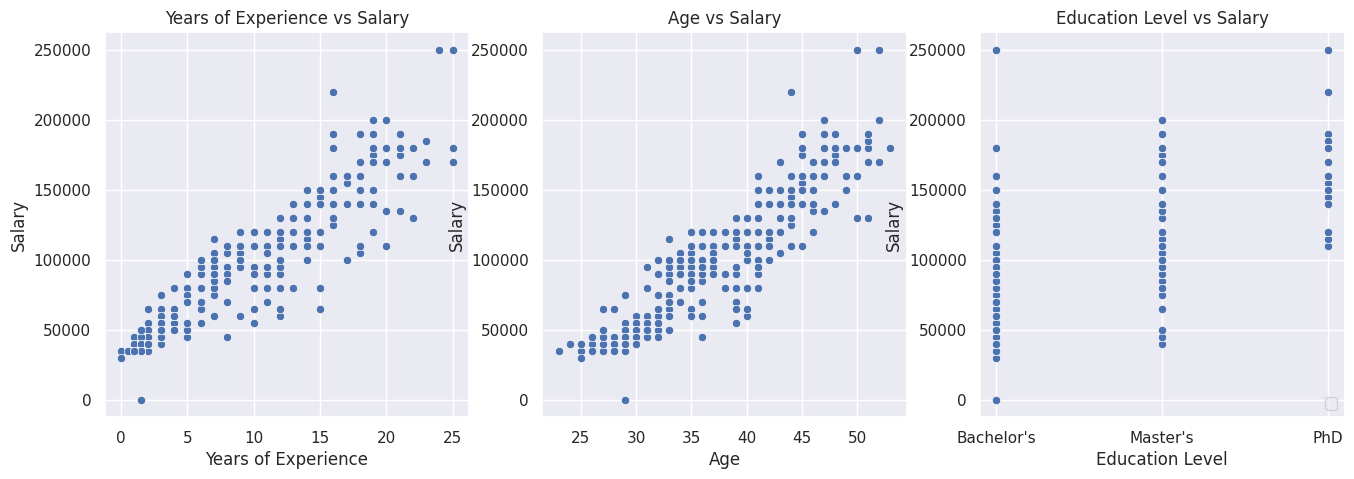

Correlation Matrix: 
                      Years of Experience       Age    Salary
Years of Experience             1.000000  0.979128  0.930338
Age                             0.979128  1.000000  0.922335
Salary                          0.930338  0.922335  1.000000


In [4]:
# load dataset
df_sal = pd.read_csv('Salary Data.csv')

X = df_sal[['Years of Experience', 'Age', 'Education Level']]
y = df_sal['Salary']

# প্রতিটি feature এর বিপরীতে Salary এর scatter plot আঁকো
fig, axes = plt.subplots(1, 3, figsize = (16, 5))

for ax, cols in zip(axes, X):
  sns.scatterplot(data = df_sal, x = cols, y = y, ax = ax).set_title(f'{cols} vs Salary')

plt.legend()
plt.show()

# correlation matrix বের করো
corr_matrix = df_sal[['Years of Experience', 'Age', 'Education Level', 'Salary']].corr(numeric_only = True)
print('Correlation Matrix: \n', corr_matrix)

# কোন feature টি সবচেয়ে strongly linear সেটা লিখে জানাও
# Ans: Years of Experience is strongly linear

# Q2. NumPy দিয়ে Prediction Function লেখো নিচের data manually define করো (অন্তত ১০টি row, ৩টি feature):
- Feature: study_hours, sleep_hours, attendance_pct → Target: exam_score
NumPy ব্যবহার করে:
- predict(X, w, b) function লেখো যেখানে y_pred = X @ w + b
- Random weights দিয়ে সব rows এর prediction করো এবং actual values এর সাথে পাশাপাশি print করো


In [11]:
# Feature: study_hours, sleep_hours, attendance_pct → Target: exam_score NumPy ব্যবহার করে:
X = np.array([
    [6, 7, 85],
    [5, 6, 78],
    [8, 8, 92],
    [4, 5, 60],
    [7, 7, 88],
    [3, 6, 55],
    [9, 8, 95],
    [5, 7, 72],
    [6, 6, 80],
    [4, 4, 50]
])

y = np.array([72, 65, 88, 55, 82, 50, 95, 68, 75, 48])

np.random.seed(42)
w = np.random.randn(3)
b = np.random.randn()

# predict(X, w, b) function লেখো যেখানে y_pred = X @ w + b
def predict(X, w, b):
   return X @ w + b

# Random weights দিয়ে সব rows এর prediction করো এবং actual values এর সাথে পাশাপাশি print করো
y_pred = predict(X, w, b)

print(f"Weights : {w}")
print(f"Bias    : {b:.4f}")
print()
print(f"{'Row':<5} {'Predicted':>12} {'Actual':>10}")
print("-" * 30)

for i in range(len(y)):
  print(f'{i+1: < 5} {y_pred[i]: > 12.2f} {y[i]: > 10}')

Weights : [ 0.49671415 -0.1382643   0.64768854]
Bias    : 1.5230

Row      Predicted     Actual
------------------------------
 1           58.59         72
 2           53.70         65
 3           63.98         88
 4           41.68         55
 5           61.03         82
 6           37.81         50
 7           66.42         95
 8           49.67         68
 9           55.49         75
 10          35.34         48


# Q3. Scikit-learn দিয়ে প্রথম Multiple Linear Regression (MLR) Model sklearn.datasets.fetch_california_housing() লোড করো।
- MedInc, AveRooms, HouseAge — শুধু এই ৩টি feature নাও
- LinearRegression দিয়ে model train করো
- coef_ এবং intercept_ print করো
- যেকোনো ৫টি sample এর predicted vs actual value দেখাও


In [14]:
# load dataset
housing = fetch_california_housing()

df_house = pd.DataFrame(housing.data, columns = housing.feature_names)

# MedInc, AveRooms, HouseAge — শুধু এই ৩টি feature নাও
X = df_house[['MedInc', 'AveRooms', 'HouseAge']].values
y = housing.target

# LinearRegression দিয়ে model train করো
model1 = LinearRegression()
model1.fit(X, y)

# coef_ এবং intercept_ print করো
w = model1.coef_
b = model1.intercept_
print('Weights:', w)
print('Bias:', b)

# যেকোনো ৫টি sample এর predicted vs actual value দেখাও
predicted_val = model1.predict(X)
print('Predicted value:', predicted_val[:5])
print('Actual value:', y[:5])

Weights: [ 0.4427634  -0.02715343  0.01682208]
Bias: 0.020406956964582168
Predicted value: [4.20656308 3.87983989 3.88341489 3.23575221 2.42753784]
Actual value: [4.526 3.585 3.521 3.413 3.422]


# Q4. MSE Cost Function implement ও visualize করো Q2 এর data ব্যবহার করো।
- NumPy দিয়ে MSE cost function লেখো: J = (1/2m) * sum((y_pred - y)^2)
- w[0] কে -10 থেকে +10 এর মধ্যে vary করো, বাকি weights fixed রাখো
- Cost এর change একটি line plot এ দেখাও এবং minimum কোথায় সেটা mark করো


Minimum Cost: 78.8396 at w[0] = 10.0000


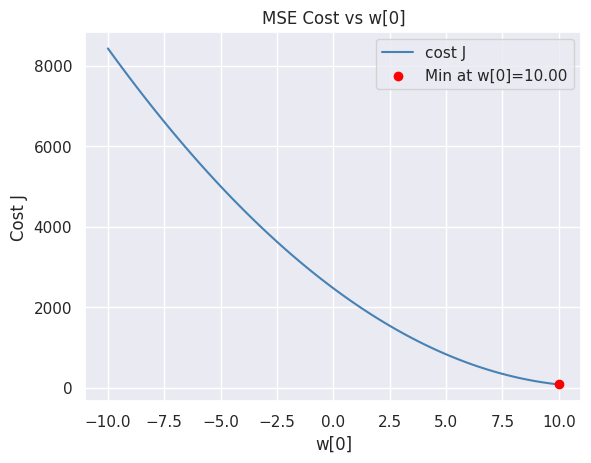

In [18]:
X = np.array([
    [6, 7, 85],
    [5, 6, 78],
    [8, 8, 92],
    [4, 5, 60],
    [7, 7, 88],
    [3, 6, 55],
    [9, 8, 95],
    [5, 7, 72],
    [6, 6, 80],
    [4, 4, 50]
])

y = np.array([72, 65, 88, 55, 82, 50, 95, 68, 75, 48])

# NumPy দিয়ে MSE cost function লেখো: J = (1/2m) * sum((y_pred - y)^2)
def compute_cost(X, y, w, b):
  m = X.shape[0]

  y_pred = X @ w + b

  cost = ( 1 / (2 * m)) * np.sum((y_pred - y) ** 2)
  return cost

# w[0] কে -10 থেকে +10 এর মধ্যে vary করো, বাকি weights fixed রাখো
w0_values = np.linspace(-10, 10, 100)
costs = []

for w0 in w0_values:
  w_temp = w.copy()
  w_temp[0] = w0
  costs.append(compute_cost(X, y, w_temp, b))

# Cost এর change একটি line plot এ দেখাও এবং minimum কোথায় সেটা mark করো
min_idx = np.argmin(costs)
min_w0 = w0_values[min_idx]
min_costs = costs[min_idx]

print(f"Minimum Cost: {min_costs:.4f} at w[0] = {min_w0:.4f}")

plt.plot(w0_values, costs, color = 'steelblue', label = 'cost J')
plt.scatter(min_w0, min_costs, color = 'red', zorder = 5, label=f'Min at w[0]={min_w0:.2f}')
plt.title('MSE Cost vs w[0]')
plt.xlabel('w[0]')
plt.ylabel('Cost J')
plt.legend()
plt.grid(True)
plt.show()

# Q5. Gradient Descent from Scratch Advertising dataset (TV, Radio, Newspaper → Sales)।
- Gradient বের করার formula implement করো: dw = (1/m) * X.T @ (y_pred - y)
- Learning rate 0.01 দিয়ে ১০০০ iteration চালাও
- প্রতি ১০০ iteration এ cost print করো
- Cost vs Iteration curve plot করো এবং কোথায় converge করেছে সেটা দেখাও


iteration: 0, cost: 0.4923, w:[0.00872783 0.00111183 0.00064617], b:-0.0000
iteration: 100, cost: 0.2299, w:[0.41627958 0.18161323 0.11830478], b:-0.1348
iteration: 200, cost: 0.1677, w:[0.56048597 0.33132906 0.2035344 ], b:-0.2354
iteration: 300, cost: 0.1463, w:[0.6348581  0.43907483 0.25030608], b:-0.2749
iteration: 400, cost: 0.1370, w:[0.67414865 0.52268549 0.27539308], b:-0.2806
iteration: 500, cost: 0.1313, w:[0.69464858 0.59262442 0.28855564], b:-0.2684
iteration: 600, cost: 0.1269, w:[0.70505084 0.65457544 0.29509685], b:-0.2472
iteration: 700, cost: 0.1229, w:[0.71003608 0.71161799 0.29789274], b:-0.2215
iteration: 800, cost: 0.1193, w:[0.71212556 0.76542655 0.29850935], b:-0.1939
iteration: 900, cost: 0.1158, w:[0.71267696 0.81691803 0.29780557], b:-0.1657


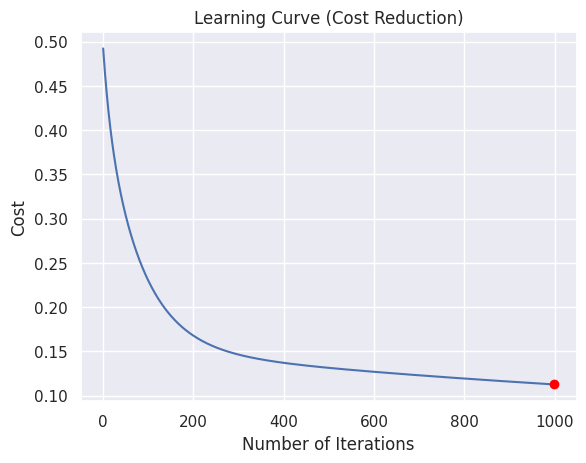

In [23]:
# load dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv'
df_ad = pd.read_csv(url)

X = df_ad[['TV', 'radio', 'newspaper']].values
y = df_ad['sales'].values

# Normalize
X = (X - X.mean()) / X.std()
y = (y - y.mean()) / y.std()

# Gradient বের করার formula implement করো: dw = (1/m) * X.T @ (y_pred - y)
m = X.shape[0]
n = X.shape[1]

def compute_cost(X, y, w, b):
  m = X.shape[0]

  y_pred =  X @ w + b
  cost = (1 / (2*m)) * np.sum((y_pred - y) ** 2)
  return cost

def compute_gradient(X, y, w, b):
  m = X.shape[0]
  y_pred = X @ w + b

  dj_dw = (1/m) * X.T @ (y_pred - y)
  dj_db = (1/m) * np.sum(y_pred - y)

  return dj_dw, dj_db

def gradient_descent(X, y, w_input, b_input, max_iter, alpha = 0.01):
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = compute_gradient(X, y, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # প্রতি ১০০ iteration এ cost print করো
    if i % 100 == 0:
      print(f'iteration: {i}, cost: {cost:.4f}, w:{w}, b:{b:.4f}')

  return w, b, cost_memo, iteration

# Learning rate 0.01 দিয়ে ১০০০ iteration চালাও
w_init = np.zeros((n))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input = w_init, b_input = b_init, max_iter = 1000, alpha = 0.01)

# Cost vs Iteration curve plot করো এবং কোথায় converge করেছে সেটা দেখাও
plt.plot(iter_list, cost_memo)

# কোথায় converge করেছে
plt.scatter(iter_list[-1], cost_memo[-1], color='red', zorder=5, label=f'Converged at {cost_memo[-1]:.4f}')

plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()